# 0. Installation

## Install the NEST simulator through conda
Install condacolab.

In [2]:
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


Install NEST through conda.

In [1]:
!mamba install -y -c conda-forge nest-simulator cmake compilers libboost-headers "sysroot_linux-64<2.34"

[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   7%
conda-forge/noarch     8%[+] 0.3s
conda-forge/linux-64  13%
conda-forge/noarch    19%[+] 0.4s
conda-forge/linux-64  20%
conda-forge/noarch    33%[+] 0.5s
conda-forge/linux-64  25%
conda-forge/noarch    43%[+] 0.6s
conda-forge/linux-64  27%
conda-forge/noarch    51%[+] 0.7s
conda-forge/linux-64  30%
conda-forge/noarch    54%[+] 0.8s
conda-forge/linux-64  35%
conda-forge/noarch    64%[+] 0.9s
conda-forge/linux-64  41%
conda-forge/noarch    75%[+] 1.0s
conda-forge/linux-64  47%
conda-forge/noarch    88%[+] 1.1s
conda-forge/linux-64  51%
conda-forge/noarch    96%conda-forge/noarch                                
[+] 1.2s
conda-forge/linux-64  60%[+] 1.3s
conda-forge/linux-64  62%[+] 1.4s
conda-forge/linux-64  65%[+] 1.5s
conda-forge/linux-64  72%[+] 1.6s
conda-forge/linux-64  77%[+] 1.7s
conda-forge/linux-64  83%[+] 1.8s
conda-forge/linux-64  88%[+] 1.9s
conda-forge/linux-64  95%[+] 2.0s

## Link this notebook to your Google Drive


This cell will open a pop up window in which Google will ask you to which Google Drive
account you want to link this notebook, so that the files you produce end up in your Drive instead of being lost when the Colab runtime is recycled.

In [3]:
from google.colab import drive, output

drive.mount("/content/drive", force_remount=True)
output.enable_custom_widget_manager()

Mounted at /content/drive


Create (or reuse) a working folder inside your Drive and move into it

In [4]:
from os import makedirs, chdir, listdir
from os.path import join

ROOT_FOLDER = "/content/drive/MyDrive/Colab Notebooks/fit_eglif_model"
makedirs(ROOT_FOLDER, exist_ok=True)
chdir(ROOT_FOLDER)

TRACES_FOLDER = join(ROOT_FOLDER, "traces_neuron")
RESULTS_FOLDER = join(ROOT_FOLDER, "results")
makedirs(RESULTS_FOLDER, exist_ok=True)

## Install BSB and cerebellar-models

Install BSB and cerebellar-cortex, it will ask you to restart your session, do so !

In [5]:
!pip install -r requirements.txt

  Cloning https://github.com/dbbs-lab/bsb.git (to revision next) to /tmp/pip-install-ssqziq9r/arborize_2e9b9e2bf8bf4299b470df97bda9016a
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/bsb.git /tmp/pip-install-ssqziq9r/arborize_2e9b9e2bf8bf4299b470df97bda9016a
  Running command git checkout -b next --track origin/next
  Switched to a new branch 'next'
  branch 'next' set up to track 'origin/next'.
  Resolved https://github.com/dbbs-lab/bsb.git to commit f0a04e82ef9ada1cbd878b81782a78770193378a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/dbbs-lab/bsb.git (to revision next) to /tmp/pip-install-ssqziq9r/nrn-patch_60259c0340aa46689b85fd967b3d77bc
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/bsb.git /tmp/pip-install-ssqziq9r/nrn-patch_60259c0340aa46689b85fd967b3d77bc
  Running command git checkout -b n

Compile NESTML models

In [6]:
!cerebellar-models build-nestml

Building NESTML models...

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

The computation had not completed because of the undecidable set membership is found in every candidates.
CMake Warning:
  Ignoring empty string ("") provided on the command line.


-- The CXX compiler identification is GNU 15.2.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
--

# 1. Fit / optimization NEST EGLIF model given neural traces from current injection protocols
## Loading and plotting traces from current injection steps

In [7]:
%matplotlib inline
%env MPLBACKEND=Agg

env: MPLBACKEND=Agg


In [8]:
import numpy as np
import pickle
import json
import nest
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

from optimization.features import multicomp_features, point_neuron_features
from optimization.fitness import (
    rheobase_loss, currents_above_thr, curvature_loss, gap_loss, _fi_curve, slope_loss,
    pacemaking_loss, cv_loss, post_first_spike_loss,
    post_rebound_loss, time_to_first_spike_loss, poststim_autorhythm_loss
)
from optimization.utils import load_experiments_files, run_nest_batch, reset_nest, nest_single_sim
from optimization.plotting import plot_fi_curve, plot_raster, plot_experiment_traces


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [9]:
# Set cell type
cell_type = "PC_sca6"

# Load experiment protocol
with open(join(TRACES_FOLDER, "protocols.json"), 'r') as file:
    protocol = json.load(file)[cell_type]
print(f"Protocol: {json.dumps(protocol, indent=4)}")

# Load traces
traces, inj_currents = load_experiments_files(
    join(TRACES_FOLDER, cell_type),
    stim_start = protocol["stim_start"],
    stim_end = protocol["stim_end"]
)
print(
  f"First trace:\n\t{str(traces[0]).replace(",", ",\n")},\n\t"
  f"injected_current: {inj_currents[0]}"
)

Protocol: {
    "stim_start": 200.0,
    "stim_end": 700.0,
    "duration": 2000.0,
    "threshold": -43
}
curr:  -900.0
curr:  -600.0
curr:  -300.0
curr:  -200.0
curr:  -100.0
curr:  0.0
curr:  100.0
curr:  200.0
curr:  300.0
curr:  400.0
curr:  500.0
curr:  600.0
First trace:
	{'T': array([0.000000e+00,
 2.500000e-02,
 5.000000e-02,
 ...,
 1.999950e+03,

       1.999975e+03,
 2.000000e+03]),
 'V': array([-65.        ,
 -64.93617054,
 -64.88859368,
 ...,
 -64.3977275 ,

       -64.39114916,
 -64.38457732]),
 'stim_start': [200.0],
 'stim_end': [700.0]},
	injected_current: -900.0


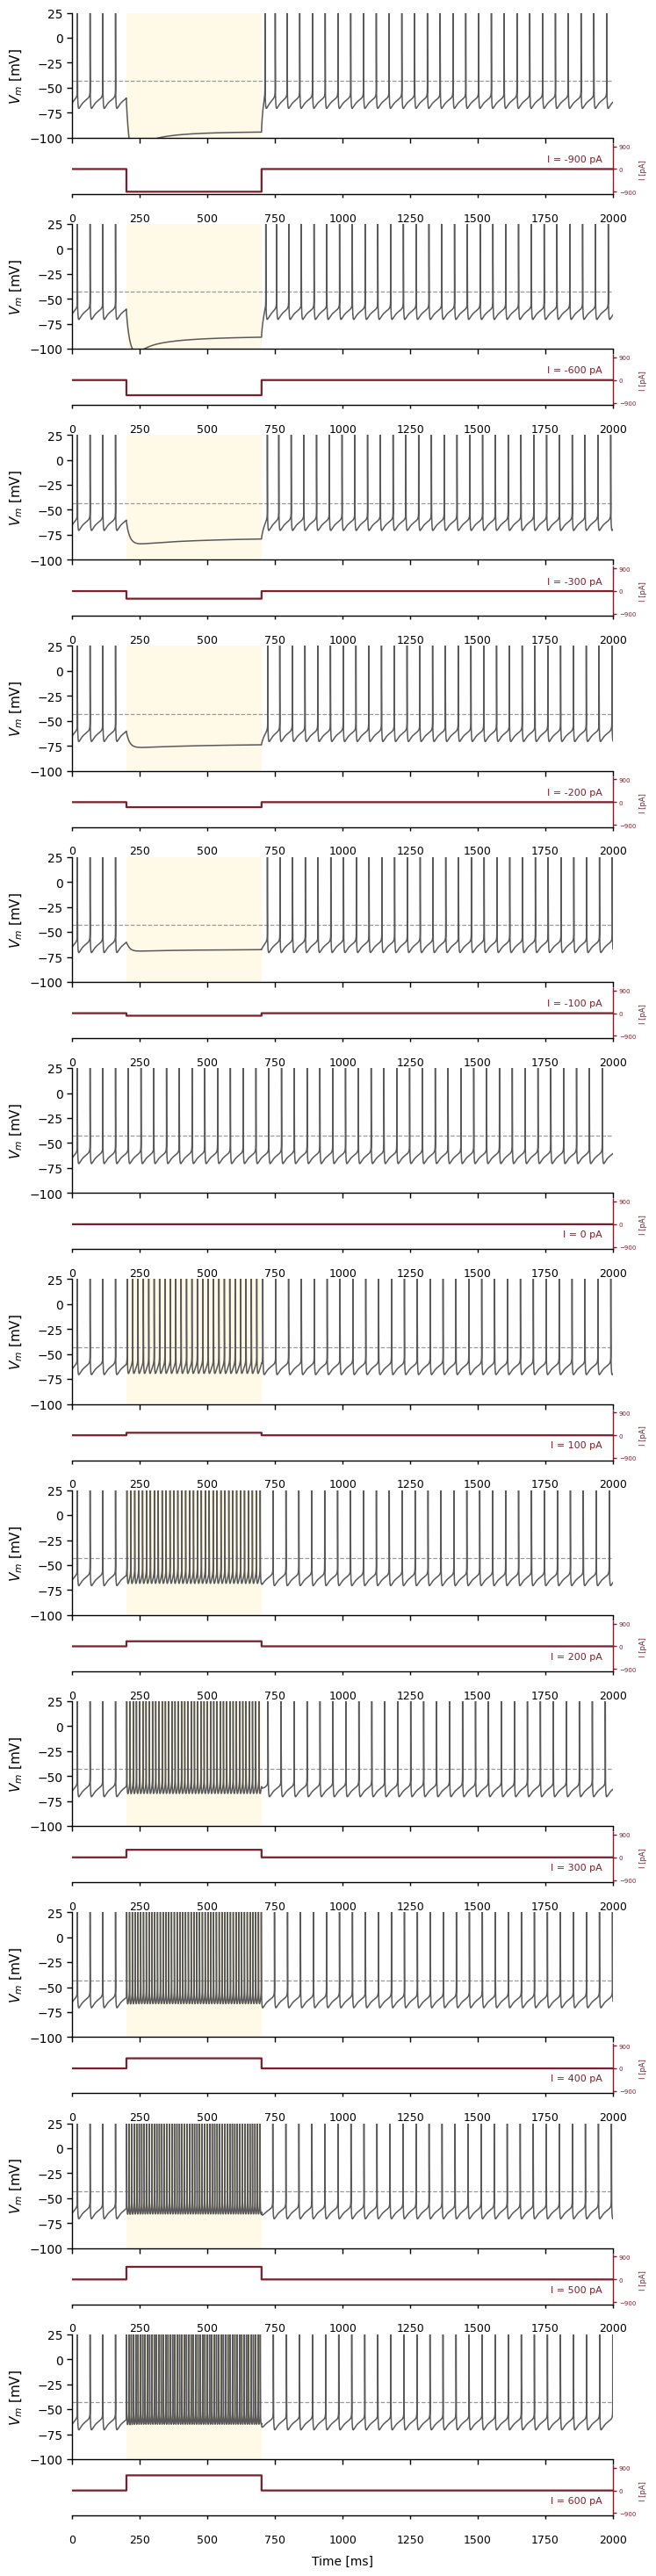

In [10]:
# Plot traces and save plot
makedirs(join(ROOT_FOLDER, "results", cell_type), exist_ok=True)
fig = plot_experiment_traces(traces, protocol, inj_currents)
fig.show()
fig.savefig(
    join(RESULTS_FOLDER, cell_type, "experiment_traces.png"),
    dpi=700, bbox_inches="tight"
)

## Computing features from experimental traces: [efel](https://efel.readthedocs.io/en/stable/eFeatures.html) tool

In [11]:
neuron_features = multicomp_features(
    traces,
    inj_currents,
    threshold = protocol["threshold"]
)
neuron_features.keys()

/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating adaptation_index, Parameter [offset] is missing in the map. In the python interface, this can be set using the appropriate setting function
An error occurred while computing the feature, feature is not found. Minimum 4 spikes needed for feature [adaptation_index].


Index(['current', 'peak_time', 'time_to_first_spike', 'time_to_second_spike',
       'time_to_last_spike', 'inv_first_ISI', 'inv_second_ISI',
       'inv_third_ISI', 'inv_fourth_ISI', 'inv_fifth_ISI', 'inv_last_ISI',
       'ISI_log_slope', 'ISI_CV', 'adaptation_index', 'spike_count_stimint',
       'mean_frequency'],
      dtype='str')

In [12]:
neuron_features['mean_frequency']

0                   [-0.0]
1                   [-0.0]
2                   [-0.0]
3                   [-0.0]
4                   [-0.0]
5      [22.95013561443361]
6     [51.824212271964164]
7      [70.70707070705792]
8      [85.66183968997028]
9      [98.19639278555336]
10    [109.22330097085405]
11    [119.11972541891649]
Name: mean_frequency, dtype: object

## Repeat same current step injection protocol in NEST and extract same features

/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
SetStatus() is deprecated and will be removed in a future version of NEST. Instead of SetStatus(nrns|conns, args), use nrns|conns.set(args).
/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
GetStatus() is deprecated and will be removed in a future version of NEST. Instead of GetStatus(nrns|conns, args), use nrns|conns.get(args).


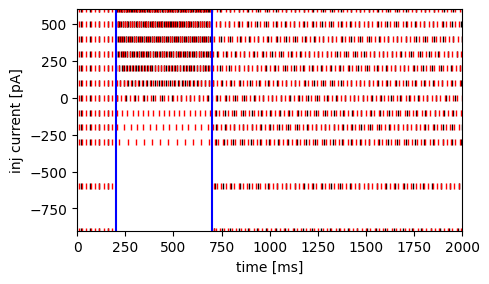

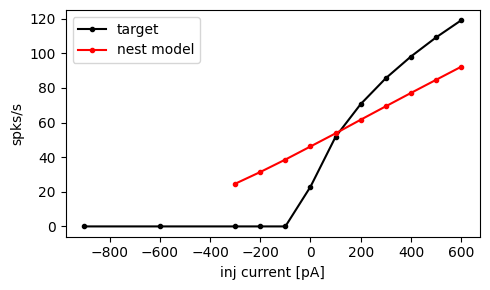

In [13]:
# NEST eglif model
nest_model = "eglif_multirec"

# Load eglif init parameters
with open(join(TRACES_FOLDER, "neuron_params.json"), 'r') as file:
    cell_params = json.load(file)[cell_type]

# NEST eglif simulations
spike_trains = run_nest_batch(nest_model, inj_currents, protocol, cell_params)
orig_nest_features = point_neuron_features(
    spike_trains = spike_trains,
    currents = inj_currents,
    stim_start = protocol["stim_start"],
    stim_end = protocol["stim_end"],
)

makedirs(join(RESULTS_FOLDER, cell_type), exist_ok=True)
# Raster plot
fig = plot_raster(neuron_features, orig_nest_features, inj_currents, protocol)
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'init_raster.png'), dpi=700, bbox_inches="tight")

# FI curve
fig = plot_fi_curve(neuron_features, orig_nest_features, labels=["target", "nest model"])
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'init_fI.png'), dpi=700, bbox_inches="tight")

# Define the objective function of the optimization problem

In [14]:
# 1. Rheobase error: min current to emit spike
rheo, thr = rheobase_loss(orig_nest_features, neuron_features)
sel = currents_above_thr(neuron_features, thr)
# 2. Slope error: weighed (by sqrt current) median of fI slope
slope = slope_loss(neuron_features, orig_nest_features, thr, sel)
# 3. Difference between fI curve curvatures
curv = curvature_loss(neuron_features, orig_nest_features, sel, use_max_slope_penalty=True)
# 4. Mean absolute error between fI curves
gap = gap_loss(neuron_features, orig_nest_features, sel, weighted="gaussian")

print(f"Rheobase error: {rheo}")
print(f"Slope error: {slope}")
print(f"Curvature error: {curv}")
print(f"Gap error: {gap}")

Rheobase error: 0.9999999999966667
Slope error: 0.17666577997848668
Curvature error: 0.5401503575287343
Gap error: 0.25627901855307134


#### 📝 Exercise

Test the same obj function used for the granule cell.

If not enough try adding loss terms able to take into account properties of the spontaneous firing rhythm (refer to `optimization.fitness`)


```
# pacemaking = pacemaking_loss(.,.)
# first_spike_loss = time_to_first_spike_loss(.,.)
# poststim_loss = poststim_autorhythm_loss(.,.,.)
```




PC shows spontaneous activity at rest.

After negative current injection, it resumes its spontaneous firing rhythm.

Need to add other loss terms (refer to `optimization.fitness`)

#### ✅ Solution
Double click on this cell to show it.
<!--
```python
# 5. Loss between mean freqs at rest
pacemaking = pacemaking_loss(neuron_features, orig_nest_features)
# 6. Loss ISI CV
cv_err = cv_loss(neuron_features, orig_nest_features)
# 7. Error between times of first spike after stim (when spiking during protocol)
pos_loss = post_first_spike_loss(neuron_features, orig_nest_features, protocol, thr=thr)
# 8. Error between times of first spike after stim (when not spiking during protocol)
neg_loss = post_first_spike_loss(neuron_features, orig_nest_features, protocol, thr=thr, sign="neg")
# 9. Error between times of first ever emitted spike
first_spike_loss = time_to_first_spike_loss(neuron_features, orig_nest_features)
# 10. Diffenrence between spontaneous activity after stim
poststim_loss = poststim_autorhythm_loss(neuron_features, orig_nest_features, protocol, thr, transient=0)

print(f"Pacemaking: {pacemaking}")
print(f"cv err: {cv_err}")
print(f"Fist spike after i>0 loss: {pos_loss}")
print(f"Fist spike after i<0 loss: {neg_loss}")
print(f"First spike loss: {first_spike_loss}")
print(f"Poststim loss: {poststim_loss}")
```
-->

In [23]:
def cell_obj_function(x, target_features, protocol, cell_params, name_opt_params, nest_model="eglif_multirec"):
    # Set NEST params
    loc_cell_params = cell_params.copy()

    # Update loc_cell_params with the parameters being optimized
    for i, name_i in enumerate(name_opt_params):
        loc_cell_params[name_i] = x[i]

    inj_currents = target_features["current"].values
    spike_trains = run_nest_batch(nest_model, inj_currents, protocol, loc_cell_params)
    nest_features = point_neuron_features(
        spike_trains = spike_trains,
        currents = inj_currents,
        stim_start = protocol["stim_start"],
        stim_end = protocol["stim_end"],
    )
    # Define the objective function
    # 1. Rheobase error: min current to emit spike
    rheo, thr = rheobase_loss(nest_features, target_features)
    sel = currents_above_thr(target_features, thr)
    # 2. Slope error: weighed (by sqrt current) median of fI slope
    slope = slope_loss(target_features, nest_features, thr, sel)
    # 3. Difference between fI curve curvatures
    curv = curvature_loss(target_features, nest_features, sel, use_max_slope_penalty=True)
    # 4. Mean absolute error between fI curves
    gap = gap_loss(target_features, nest_features, sel, weighted="gaussian")

    loss_terms = [rheo, slope, curv, gap]
    if np.any(np.isnan(loss_terms)):
        return len(loss_terms)
    return np.sum(loss_terms)

## Set opt problem

In [24]:
# Load bounds
with open(join(TRACES_FOLDER, "opt_bounds.json"), 'r') as file:
    cell_bounds = json.load(file)[cell_type]

bounds = []
name_opt_params = []
for name_i, bounds_i in cell_bounds.items():
    bounds.append(bounds_i)
    name_opt_params.append(name_i)

# Initial values of the parameters to optimize
x0 = []
x0 += [cell_params[name_i] for name_i in name_opt_params]

# Set their bounds
bounds = []
bounds += [(bounds_i[0], bounds_i[1]) for bounds_i in cell_bounds.values()]

# Solving optimization: differential_evolution from scipy.optimize is an
# evolutionary algorithm (not based on gradient) that updates a condidate
# solution by combining existing ones
res = differential_evolution(
    cell_obj_function,
    bounds=bounds,
    args=(neuron_features, protocol, cell_params, name_opt_params),
    strategy='best1bin',
    maxiter=int(1e3),
    popsize=2,
    mutation=(0.5, 1.0),
    recombination=0.7,
    rng=42,
    # workers=1,           # Uses all available CPU cores (-1)
    # updating="deferred"   # Processes whole generations in parallel
)

/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/pytho

In [25]:
# Show results
for i, name_i in enumerate(name_opt_params):
    print(name_i, ": ", res.x[i])

print("Final loss : ",  res.fun)

A1 :  1043.7345218245837
A2 :  51.52955550618691
I_e :  39.339119357529
k_1 :  0.10834443531826865
k_2 :  0.0307041503337716
k_adap :  0.25740461446093205
Final loss :  1.600336803303806


# Evaluate solution

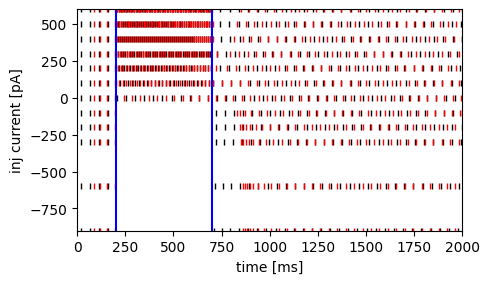

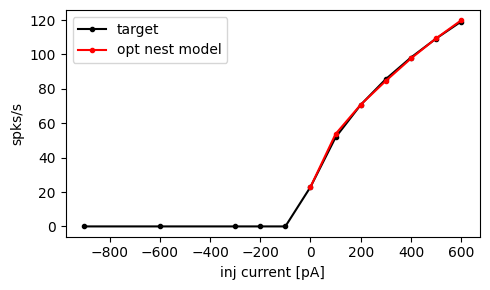

In [26]:
# NEST opt params
cell_params_opt = cell_params.copy()
for i, name_i in enumerate(name_opt_params):
    cell_params_opt[name_i] = res.x[i]

# Repeat current step injection protocol in NEST on the optimal solution
spike_trains = run_nest_batch(nest_model, inj_currents, protocol, cell_params_opt)
nest_features_opt = point_neuron_features(
    spike_trains = spike_trains,
    currents = inj_currents,
    stim_start = protocol["stim_start"],
    stim_end = protocol["stim_end"],
)

# Raster plot
fig = plot_raster(neuron_features, nest_features_opt, inj_currents, protocol)
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'opt_raster.png'), dpi=700, bbox_inches="tight")

# Inspect fI curves
fig = plot_fi_curve(neuron_features, nest_features_opt, labels=["target", "opt nest model"])
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'opt_fI.png'), dpi=700, bbox_inches="tight")

In [27]:
# Save results
pickle.dump({'res': res,
              'cell_params_opt': cell_params_opt
              },
            open(join(RESULTS_FOLDER, cell_type, 'opt_res.pickle'), 'wb'),
            protocol = pickle.HIGHEST_PROTOCOL
)